# Brain Tumor Segmentation — BraTS 2020 with U-Net

The task is to perform **semantic segmentation of brain tumors** from multimodal MRI scans in the **BraTS 2020** dataset.

Each patient contains four MRI modalities:

- **T1**
- **T1ce / T1Gd**
- **T2**
- **FLAIR**

The segmentation mask uses the original BraTS labels:

- `0` — background
- `1` — NCR/NET: necrotic and non-enhancing tumor core
- `2` — ED: peritumoral edema
- `4` — ET: enhancing tumor

For training we remap label `4 -> 3`, obtaining four consecutive classes `[0, 1, 2, 3]`.

In this notebook we build a **2D U-Net baseline** that receives the four MRI modalities as four input channels and predicts a multiclass segmentation mask for each axial slice.

> **Important:** the official BraTS 2020 validation set does not provide public ground-truth segmentations.  
> For this reason, train/validation/test are obtained by splitting the **annotated training patients**, at patient level. This avoids data leakage between slices belonging to the same patient.

## Imports

In [4]:
import os

import numpy as np

import keras

from keras import layers, models

from keras.utils import PyDataset

import tensorflow as tf

import matplotlib.pyplot as plt

- `nibabel` to read NIfTI (`.nii` / `.nii.gz`) MRI volumes;
- `kagglehub` to download the Kaggle dataset directly from Colab.

In [5]:
!pip -q install nibabel kagglehub

In [6]:
import nibabel as nib
import kagglehub

## Download dataset

In [7]:
# ============================================================
# 1. DATASET DOWNLOAD
# ============================================================

DATASET_HANDLE = "talhaumar/brats2020-correct-dataset-training-validation"

try:
    DATASET_PATH = kagglehub.dataset_download(DATASET_HANDLE)
except Exception as e:
    print("Kaggle download requires authentication.")
    print("You can authenticate with your Kaggle API token.")
    print("Original error:", e)

    kagglehub.login()
    DATASET_PATH = kagglehub.dataset_download(DATASET_HANDLE)

print("Dataset path:", DATASET_PATH)

Dataset path: /kaggle/input/datasets/talhaumar/brats2020-correct-dataset-training-validation


## Runtime / GPU check

In [8]:
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        print("\nGPU details:")
        print(tf.config.experimental.get_device_details(gpu))
else:
    print("\nNo GPU found. In Colab select Runtime -> Change runtime type -> GPU.")

TensorFlow version: 2.20.0
Keras version: 3.13.2

GPU details:
{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}

GPU details:
{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}


# Dataset analysis



In [9]:
# ============================================================
# 2. DATASET DISCOVERY
# ============================================================

def strip_nii_extension(path):
    if path.endswith(".nii.gz"):
        return path[:-7]
    if path.endswith(".nii"):
        return path[:-4]
    return path


def find_nii(prefix):
    candidates = [
        prefix + ".nii.gz",
        prefix + ".nii",
    ]

    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate

    return None


def discover_training_cases(dataset_root):
    seg_files = []

    for root, _, files in os.walk(dataset_root):
        for filename in files:
            if filename.endswith("_seg.nii") or filename.endswith("_seg.nii.gz"):
                seg_files.append(os.path.join(root, filename))

    cases = []

    for seg_path in sorted(seg_files):
        seg_base = strip_nii_extension(seg_path)

        if not seg_base.endswith("_seg"):
            continue

        prefix = seg_base[:-4]

        case = {
            "name": os.path.basename(prefix),
            "t1": find_nii(prefix + "_t1"),
            "t1ce": find_nii(prefix + "_t1ce"),
            "t2": find_nii(prefix + "_t2"),
            "flair": find_nii(prefix + "_flair"),
            "seg": seg_path,
        }

        required = ["t1", "t1ce", "t2", "flair", "seg"]

        if all(case[key] is not None for key in required):
            cases.append(case)

    return cases


cases = discover_training_cases(DATASET_PATH)

print("Annotated training cases found:", len(cases))

if len(cases) == 0:
    raise RuntimeError(
        "No annotated BraTS cases were found. "
        "Inspect DATASET_PATH and verify that the Kaggle download completed correctly."
    )

print("\nExample case:")
for key, value in cases[0].items():
    print(f"{key:>6}: {value}")

Annotated training cases found: 369

Example case:
  name: BraTS20_Training_001
    t1: /kaggle/input/datasets/talhaumar/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1.nii
  t1ce: /kaggle/input/datasets/talhaumar/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii
    t2: /kaggle/input/datasets/talhaumar/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t2.nii
 flair: /kaggle/input/datasets/talhaumar/brats2020-correct-dataset-training-validation/BraTS2020 Dataset (Training + Validation)/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_flair.nii
   seg: /kaggle/input/datasets/talhaumar/brats2020-correct-dataset-training-validat

## Inspect one subject

In [10]:
# ============================================================
# 3. BASIC DATA INSPECTION
# ============================================================
example_case = cases[0]

for modality in ["t1", "t1ce", "t2", "flair", "seg"]:
    image = nib.load(example_case[modality])
    print(
        f"{modality:>5} | shape = {image.shape} | "
        f"dtype = {image.get_data_dtype()}"
    )

example_seg = np.asarray(nib.load(example_case["seg"]).dataobj)

print("\nUnique segmentation labels:", np.unique(example_seg))
print("Number of voxels:", example_seg.size)
print("Tumor voxels:", np.sum(example_seg > 0))
print("Tumor percentage:", 100 * np.mean(example_seg > 0), "%")

   t1 | shape = (240, 240, 155) | dtype = int16
 t1ce | shape = (240, 240, 155) | dtype = int16
   t2 | shape = (240, 240, 155) | dtype = int16
flair | shape = (240, 240, 155) | dtype = int16
  seg | shape = (240, 240, 155) | dtype = uint8

Unique segmentation labels: [0 1 2 4]
Number of voxels: 8928000
Tumor voxels: 211979
Tumor percentage: 2.3743167562724015 %


## Visualize modalities and ground truth

Selected axial slice: 38


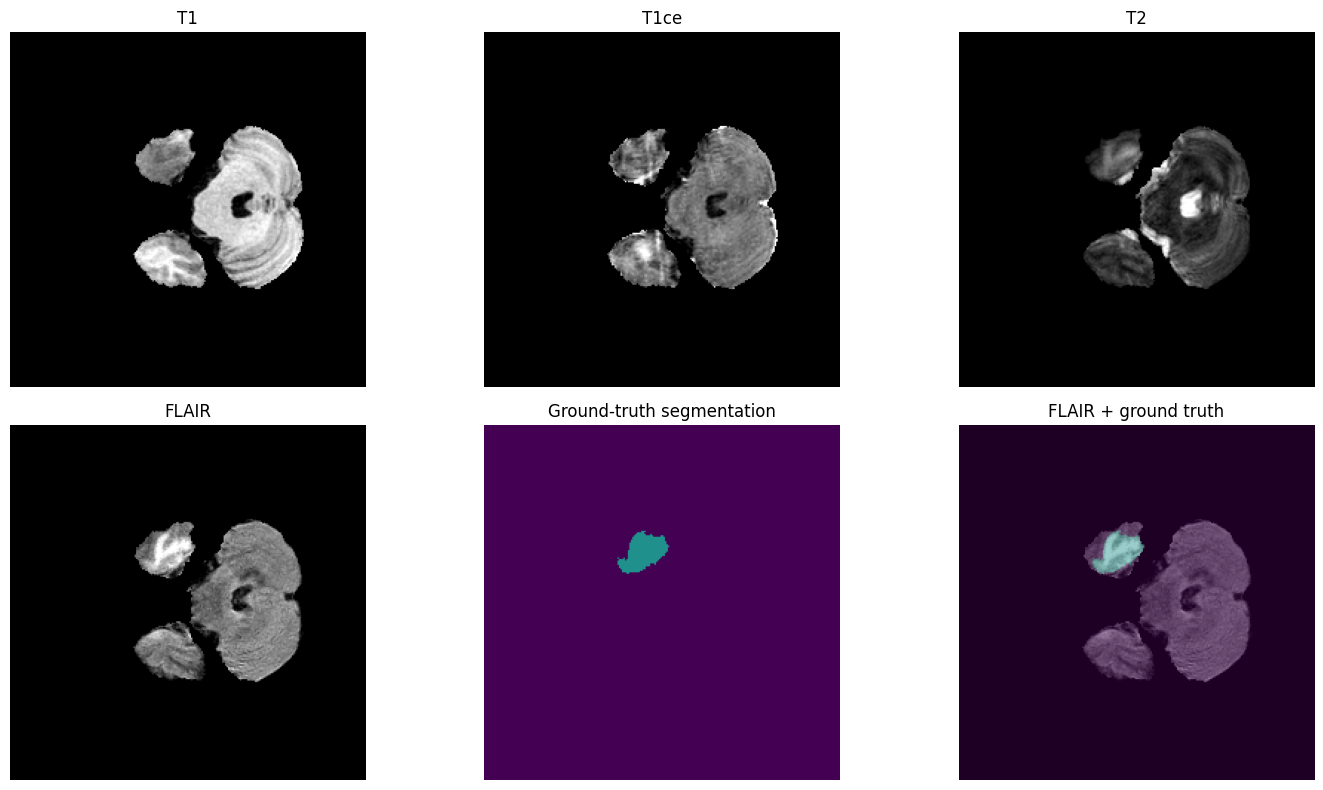

In [11]:
# ============================================================
# 4. DATASET VISUALIZATION
# ============================================================
SELECTED_SLICE = 38  # the slice goes from 0 to 155. They rappresent a 2D plane of the 3D scan.

def minmax_for_display(image):
    image = image.astype(np.float32)
    nonzero = image[image != 0]

    if len(nonzero) == 0:
        return image

    low = np.percentile(nonzero, 1)
    high = np.percentile(nonzero, 99)

    image = np.clip(image, low, high)
    image = (image - low) / (high - low + 1e-8)

    return image


def load_slice(path, z):
    nii = nib.load(path)
    return np.asarray(nii.dataobj[:, :, SELECTED_SLICE], dtype=np.float32)


# Select the axial slice containing the largest tumor area.
seg_volume = np.asarray(nib.load(example_case["seg"]).dataobj)
tumor_area_per_slice = np.sum(seg_volume > 0, axis=(0, 1))
z = int(np.argmax(tumor_area_per_slice))

print("Selected axial slice:", SELECTED_SLICE)

t1 = minmax_for_display(load_slice(example_case["t1"], SELECTED_SLICE))
t1ce = minmax_for_display(load_slice(example_case["t1ce"], SELECTED_SLICE))
t2 = minmax_for_display(load_slice(example_case["t2"], SELECTED_SLICE))
flair = minmax_for_display(load_slice(example_case["flair"], SELECTED_SLICE))
seg = seg_volume[:, :, SELECTED_SLICE]

plt.figure(figsize=(15, 8))

images = [t1, t1ce, t2, flair]
titles = ["T1", "T1ce", "T2", "FLAIR"]

for i, (image, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(seg, cmap="viridis", vmin=0, vmax=4)
plt.title("Ground-truth segmentation")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(flair, cmap="gray")
plt.imshow(seg, cmap="viridis", alpha=0.45, vmin=0, vmax=4)
plt.title("FLAIR + ground truth")
plt.axis("off")

plt.tight_layout()
plt.show()

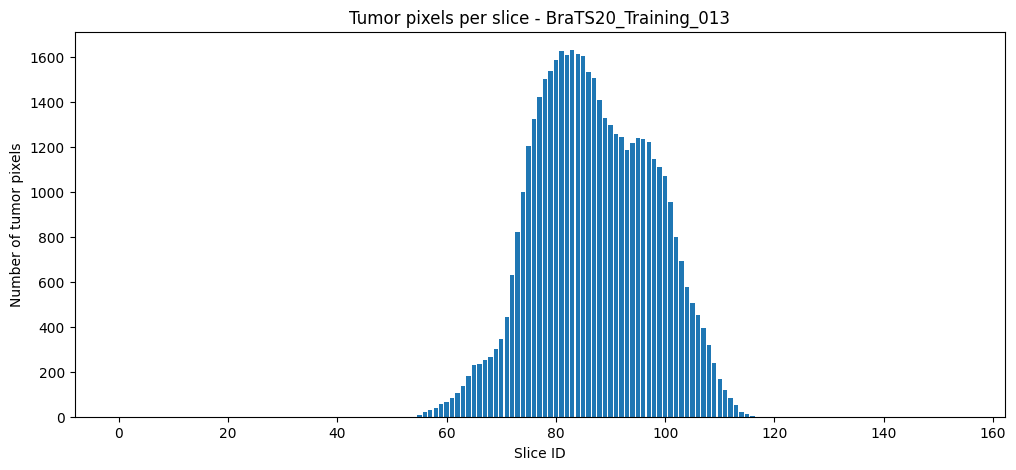

In [12]:
# ============================================================
# TUMOR PIXELS PER SLICE
# ============================================================

PATIENT_ID = 12

case = cases[PATIENT_ID]

seg_volume = np.asarray(
    nib.load(case["seg"]).dataobj,
    dtype=np.uint8
)

tumor_pixels_per_slice = np.sum(
    seg_volume > 0,
    axis=(0, 1)
)

plt.figure(figsize=(12, 5))

plt.bar(
    np.arange(seg_volume.shape[2]),
    tumor_pixels_per_slice
)

plt.title(f"Tumor pixels per slice - {case['name']}")
plt.xlabel("Slice ID")
plt.ylabel("Number of tumor pixels")

plt.show()

Distribution shape: (369, 155)


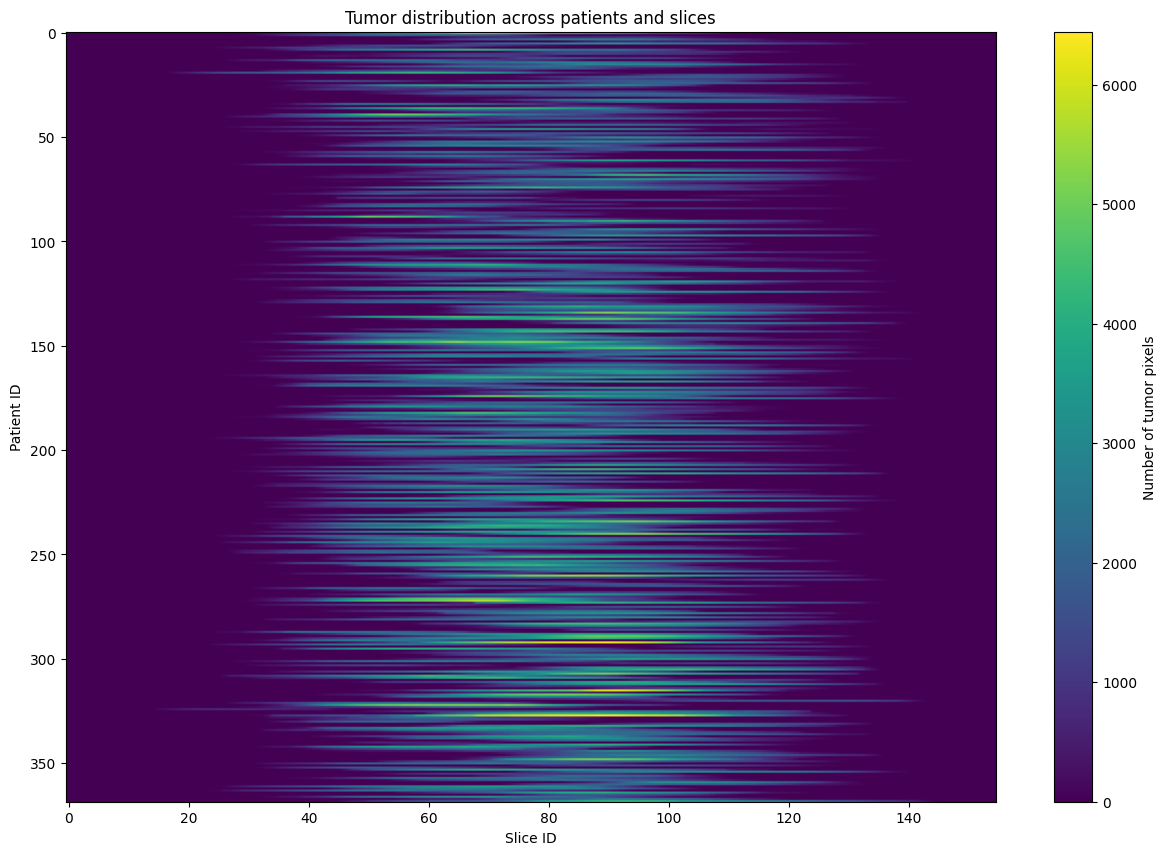

In [13]:
# ============================================================
# TUMOR DISTRIBUTION ACROSS ALL PATIENTS
# ============================================================

tumor_distribution = []

for i, case in enumerate(cases):

    seg_volume = np.asarray(
        nib.load(case["seg"]).dataobj,
        dtype=np.uint8
    )

    # Number of tumor pixels in every slice
    tumor_pixels_per_slice = np.sum(
        seg_volume > 0,
        axis=(0, 1)
    )

    tumor_distribution.append(tumor_pixels_per_slice)

tumor_distribution = np.asarray(tumor_distribution)

plt.figure(figsize=(15, 10))

plt.imshow(
    tumor_distribution,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(
    label="Number of tumor pixels"
)

plt.xlabel("Slice ID")
plt.ylabel("Patient ID")

plt.title(
    "Tumor distribution across patients and slices"
)

print("Distribution shape:", tumor_distribution.shape)
plt.show()

# Train / validation / test split

The split is performed **by patient**, not by individual slice.

If slices from the same MRI volume were randomly distributed across train and test, the evaluation would be artificially optimistic because neighboring slices are highly correlated.

In [14]:
# ============================================================
# 5. PATIENT-LEVEL SPLIT
# ============================================================

SEED = 42
keras.utils.set_random_seed(SEED)

rng = np.random.default_rng(SEED)

indices = np.arange(len(cases))
rng.shuffle(indices)

n_total = len(indices)
n_train = int(0.80 * n_total)
n_val = int(0.10 * n_total)

train_cases = [cases[i] for i in indices[:n_train]]
val_cases = [cases[i] for i in indices[n_train:n_train + n_val]]
test_cases = [cases[i] for i in indices[n_train + n_val:]]

print("Train cases:", len(train_cases))
print("Validation cases:", len(val_cases))
print("Test cases:", len(test_cases))
print("Total:", len(train_cases) + len(val_cases) + len(test_cases))

Train cases: 295
Validation cases: 36
Test cases: 38
Total: 369


# Preprocessing

For a first Colab-friendly experiment we use a **2D U-Net** instead of a full 3D network.

For each selected axial slice:

1. load T1, T1ce, T2 and FLAIR;
2. normalize each modality using z-score normalization on non-zero brain pixels;
3. stack the four modalities into an `(H, W, 4)` tensor;
4. resize to `128 x 128`;
5. resize the segmentation mask with nearest-neighbor interpolation;
6. remap the original BraTS label `4` to class index `3`.


In [15]:
# ============================================================
# 6. PREPROCESSING SETTINGS
# ============================================================

IMG_SIZE = 128   # Original is 240x240
N_CHANNELS = 4   # Background , Edema , ...
N_CLASSES = 4    # T1,T1ce, T2 , Flair
BATCH_SIZE = 8

first_shape = nib.load(cases[0]["seg"]).shape
DEPTH = first_shape[2]

SLICE_IDS = [x for x in range(20,140)] # The range 20-140 is based on visualization above
SLICES_PER_CASE = len(SLICE_IDS)
print("Original volume shape:", first_shape)
print("Selected slices:", SLICE_IDS)
print("Slide per case : " , SLICES_PER_CASE)

Original volume shape: (240, 240, 155)
Selected slices: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139]
Slide per case :  120


In [16]:
def normalize_mri_slice(image):
    image = image.astype(np.float32)

    brain = image != 0

    if np.any(brain):
        mean = image[brain].mean()
        std = image[brain].std()

        image[brain] = (image[brain] - mean) / (std + 1e-8)

        # Limit extreme outliers.
        image = np.clip(image, -5.0, 5.0)

    return image


def remap_mask(mask):
    mask = mask.astype(np.uint8).copy()

    # Original BraTS labels: 0, 1, 2, 4
    # Keras classes:          0, 1, 2, 3
    mask[mask == 4] = 3

    return mask


def preprocess_slice(modality_slices, mask):
    # Stack T1, T1ce, T2, FLAIR.
    x = np.stack(
        [normalize_mri_slice(img) for img in modality_slices],
        axis=-1
    )

    x = tf.image.resize(
        x,
        (IMG_SIZE, IMG_SIZE),
        method="bilinear"
    ).numpy()

    mask = tf.image.resize(
        mask[..., None],
        (IMG_SIZE, IMG_SIZE),
        method="nearest"
    ).numpy()[..., 0]

    mask = remap_mask(mask)

    return x.astype(np.float32), mask.astype(np.uint8)

## Keras `PyDataset`

In [17]:
# ============================================================
# 7. DATA GENERATOR
# ============================================================

class BratsSliceDataset(PyDataset):
    def __init__(
        self,
        cases,       # Patient list
        slice_ids,   # Slide list
        batch_size=8,
        shuffle_cases=False,
        augment=False,
        seed=42,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.cases = list(cases)
        self.slice_ids = np.asarray(slice_ids, dtype=int)
        self.batch_size = batch_size
        self.shuffle_cases = shuffle_cases
        self.augment = augment
        self.rng = np.random.default_rng(seed)

        self.case_order = np.arange(len(self.cases))

        # Lightweight cache: keep NIfTI handles for the most recently used case.
        self._cached_case_name = None
        self._cached_handles = None

        self._build_batches()

    def _build_batches(self):
        self.batches = []

        for case_idx in self.case_order:
            for start in range(0, len(self.slice_ids), self.batch_size):
                batch_slices = self.slice_ids[start:start + self.batch_size]
                self.batches.append((case_idx, batch_slices))

    def __len__(self):
        return len(self.batches)

    def _get_handles(self, case):
        if self._cached_case_name != case["name"]:
            self._cached_handles = {
                "t1": nib.load(case["t1"]),
                "t1ce": nib.load(case["t1ce"]),
                "t2": nib.load(case["t2"]),
                "flair": nib.load(case["flair"]),
                "seg": nib.load(case["seg"]),
            }

            self._cached_case_name = case["name"]

        return self._cached_handles

    def __getitem__(self, batch_idx):
        case_idx, z_values = self.batches[batch_idx]

        case = self.cases[case_idx]
        handles = self._get_handles(case)

        x_batch = []
        y_batch = []

        for z in z_values:
            modality_slices = [
                np.asarray(handles["t1"].dataobj[:, :, z], dtype=np.float32),
                np.asarray(handles["t1ce"].dataobj[:, :, z], dtype=np.float32),
                np.asarray(handles["t2"].dataobj[:, :, z], dtype=np.float32),
                np.asarray(handles["flair"].dataobj[:, :, z], dtype=np.float32),
            ]

            mask = np.asarray(
                handles["seg"].dataobj[:, :, z],
                dtype=np.uint8
            )

            x, y = preprocess_slice(modality_slices, mask)

            # Very simple augmentation for the training set.
            if self.augment and self.rng.random() < 0.5:
                x = np.flip(x, axis=1).copy()
                y = np.flip(y, axis=1).copy()

            x_batch.append(x)
            y_batch.append(y)

        return (
            np.stack(x_batch).astype(np.float32),
            np.stack(y_batch).astype(np.uint8)
        )

    def on_epoch_end(self):
        if self.shuffle_cases:
            self.rng.shuffle(self.case_order)
            self._build_batches()

In [18]:
train_generator = BratsSliceDataset(
    train_cases,
    SLICE_IDS,
    batch_size=BATCH_SIZE,
    shuffle_cases=True,
    augment=True,
    seed=SEED,
    workers=1,
    use_multiprocessing=False,
    max_queue_size=2
)

val_generator = BratsSliceDataset(
    val_cases,
    SLICE_IDS,
    batch_size=BATCH_SIZE,
    shuffle_cases=False,
    augment=False,
    seed=SEED,
    workers=1,
    use_multiprocessing=False,
    max_queue_size=2
)

test_generator = BratsSliceDataset(
    test_cases,
    SLICE_IDS,
    batch_size=BATCH_SIZE,
    shuffle_cases=False,
    augment=False,
    seed=SEED,
    workers=1,
    use_multiprocessing=False,
    max_queue_size=2
)

print("Train batches:", len(train_generator))
print("Validation batches:", len(val_generator))
print("Test batches:", len(test_generator))

Train batches: 4425
Validation batches: 540
Test batches: 570


## Inspect a preprocessed batch

In [19]:
ID = 20        # from 0 to len(train_generator)
BATCH_ID = 6  # from 0 to BATCH_SIZE


x_batch, y_batch = train_generator[ID]

print("Input batch shape:", x_batch.shape)
print("Target batch shape:", y_batch.shape)
print("Input dtype:", x_batch.dtype)
print("Target dtype:", y_batch.dtype)
print("Target classes:", np.unique(y_batch))

Input batch shape: (8, 128, 128, 4)
Target batch shape: (8, 128, 128)
Input dtype: float32
Target dtype: uint8
Target classes: [0 1 2 3]


I0000 00:00:1788872768.609781      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788872768.612733      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


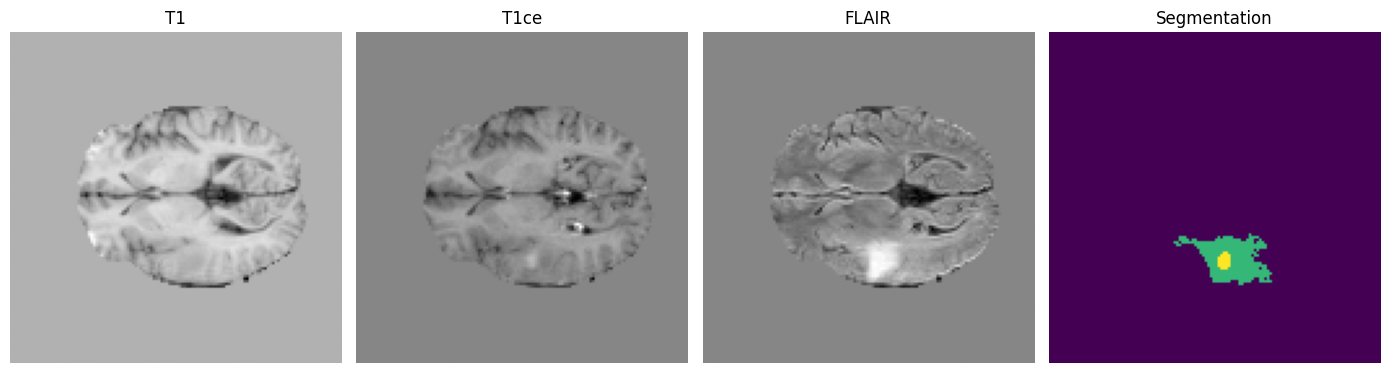

In [20]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(x_batch[BATCH_ID, :, :, 0], cmap="gray")
plt.title("T1")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(x_batch[BATCH_ID, :, :, 1], cmap="gray")
plt.title("T1ce")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(x_batch[BATCH_ID, :, :, 3], cmap="gray")
plt.title("FLAIR")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(y_batch[BATCH_ID], cmap="viridis", vmin=0, vmax=3)
plt.title("Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

# Baseline

A useful sanity-check baseline is the trivial classifier that predicts **background everywhere**.

Because most MRI pixels are background, this baseline can obtain deceptively high pixel accuracy while obtaining essentially zero Dice on tumor regions. This demonstrates why segmentation metrics such as Dice and IoU are necessary.

In [21]:
# ============================================================
# 8. SEGMENTATION METRICS
# ============================================================

REGIONS = {
    # After remapping label 4 -> 3.
    "ET": lambda m: m == 3,
    "TC": lambda m: np.isin(m, [1, 3]),
    "WT": lambda m: m > 0,
}


def evaluate_predictions(generator, predict_fn, max_batches=None):
    stats = {
        name: {
            "intersection": 0,
            "pred_sum": 0,
            "true_sum": 0,
            "union": 0
        }
        for name in REGIONS
    }

    correct_pixels = 0
    total_pixels = 0

    n_batches = len(generator)

    if max_batches is not None:
        n_batches = min(n_batches, max_batches)

    for i in range(n_batches):
        print(
            f"\rEvaluating batch {i + 1}/{n_batches}",
            end="",
            flush=True
        )

        x, y_true = generator[i]
        y_pred = predict_fn(x, y_true)

        correct_pixels += np.sum(y_pred == y_true)
        total_pixels += y_true.size

        for name, region_fn in REGIONS.items():
            true_region = region_fn(y_true)
            pred_region = region_fn(y_pred)

            intersection = np.logical_and(
                true_region,
                pred_region
            ).sum()

            union = np.logical_or(
                true_region,
                pred_region
            ).sum()

            stats[name]["intersection"] += intersection
            stats[name]["pred_sum"] += pred_region.sum()
            stats[name]["true_sum"] += true_region.sum()
            stats[name]["union"] += union

    print()

    results = {}

    for name, s in stats.items():
        dice = (
            2.0 * s["intersection"] /
            (s["pred_sum"] + s["true_sum"] + 1e-8)
        )

        iou = (
            s["intersection"] /
            (s["union"] + 1e-8)
        )

        results[f"{name}_dice"] = float(dice)
        results[f"{name}_iou"] = float(iou)

    results["mean_dice"] = float(
        np.mean([results[f"{name}_dice"] for name in REGIONS])
    )

    results["mean_iou"] = float(
        np.mean([results[f"{name}_iou"] for name in REGIONS])
    )

    results["pixel_accuracy"] = float(
        correct_pixels / (total_pixels + 1e-8)
    )

    return results


def print_metrics(metrics, title="Metrics"):
    print("\n" + title)
    print("-" * len(title))

    for key, value in metrics.items():
        print(f"{key:>16}: {value:.4f}")

In [22]:
# Background-only baseline.
baseline_metrics = evaluate_predictions(
    test_generator,
    predict_fn=lambda x, y: np.zeros_like(y)
)

print_metrics(
    baseline_metrics,
    title="Background-only baseline"
)

Evaluating batch 570/570

Background-only baseline
------------------------
         ET_dice: 0.0000
          ET_iou: 0.0000
         TC_dice: 0.0000
          TC_iou: 0.0000
         WT_dice: 0.0000
          WT_iou: 0.0000
       mean_dice: 0.0000
        mean_iou: 0.0000
  pixel_accuracy: 0.9851


# Loss and training metrics

A pure categorical cross-entropy is affected by the severe class imbalance.

We therefore combine:

- **Sparse Categorical Cross-Entropy**
- **soft Dice loss** over the three tumor classes

During training we also report:

- mean tumor Dice;
- pixel accuracy.

The final evaluation later computes the clinically more interpretable BraTS regions:

- **ET** — enhancing tumor;
- **TC** — tumor core;
- **WT** — whole tumor.

In [23]:
# ============================================================
# 11. LOSS + KERAS METRICS
# ============================================================

cce = keras.losses.SparseCategoricalCrossentropy()


def soft_dice_loss(y_true, y_pred, smooth=1e-5):
    y_true = tf.cast(y_true, tf.int32)

    if y_true.shape.rank == 4:
        y_true = tf.squeeze(y_true, axis=-1)

    y_true = tf.one_hot(
        y_true,
        depth=N_CLASSES,
        dtype=tf.float32
    )

    # Exclude background channel.
    y_true_tumor = y_true[..., 1:]
    y_pred_tumor = y_pred[..., 1:]

    axes = (0, 1, 2)

    intersection = tf.reduce_sum(
        y_true_tumor * y_pred_tumor,
        axis=axes
    )

    denominator = tf.reduce_sum(
        y_true_tumor + y_pred_tumor,
        axis=axes
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        denominator + smooth
    )

    return 1.0 - tf.reduce_mean(dice)


def combined_loss(y_true, y_pred):
    return cce(y_true, y_pred) + soft_dice_loss(y_true, y_pred)


def mean_tumor_dice(y_true, y_pred, smooth=1e-5):
    y_true = tf.cast(y_true, tf.int32)

    if y_true.shape.rank == 4:
        y_true = tf.squeeze(y_true, axis=-1)

    y_true = tf.one_hot(
        y_true,
        depth=N_CLASSES,
        dtype=tf.float32
    )

    y_pred = tf.one_hot(
        tf.argmax(y_pred, axis=-1),
        depth=N_CLASSES,
        dtype=tf.float32
    )

    y_true = y_true[..., 1:]
    y_pred = y_pred[..., 1:]

    axes = (0, 1, 2)

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=axes
    )

    denominator = tf.reduce_sum(
        y_true + y_pred,
        axis=axes
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        denominator + smooth
    )

    return tf.reduce_mean(dice)

# U-Net architecture

We now define a standard encoder-decoder **U-Net**.

The encoder progressively reduces the spatial resolution and increases the number of feature maps.  
The decoder upsamples the representation and uses skip connections from the corresponding encoder levels.

This first model intentionally remains compact enough for a normal Google Colab GPU.

In [24]:
# ============================================================
# U-NET BLOCKS
# ============================================================

def conv_block(x, filters, dropout=0.0):
    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    return x


def encoder_block(x, filters):
    skip = conv_block(x, filters)
    pooled = layers.MaxPooling2D(pool_size=2)(skip)

    return skip, pooled


def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(
        filters,
        kernel_size=2,
        strides=2,
        padding="same"
    )(x)

    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)

    return x

In [25]:
# ============================================================
# FULL U-NET
# ============================================================

def build_unet(
    input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
    n_classes=N_CLASSES,
    base_filters=16
):
    inputs = layers.Input(
        shape=input_shape,
        name="multimodal_mri"
    )

    # Encoder.
    s1, p1 = encoder_block(inputs, base_filters)
    s2, p2 = encoder_block(p1, base_filters * 2)
    s3, p3 = encoder_block(p2, base_filters * 4)
    s4, p4 = encoder_block(p3, base_filters * 8)

    # Bottleneck.
    b = conv_block(
        p4,
        base_filters * 16,
        dropout=0.20
    )

    # Decoder.
    d1 = decoder_block(b, s4, base_filters * 8)
    d2 = decoder_block(d1, s3, base_filters * 4)
    d3 = decoder_block(d2, s2, base_filters * 2)
    d4 = decoder_block(d3, s1, base_filters)

    outputs = layers.Conv2D(
        n_classes,
        kernel_size=1,
        activation="softmax",
        name="segmentation"
    )(d4)

    return models.Model(
        inputs,
        outputs,
        name="brats_2d_unet"
    )

In [30]:
# ============================================================
# MODEL U-NET DEFINITION
# ============================================================

unet_model = build_unet()
unet_model.summary()
num_params = unet_model.count_params()

print(f"\nTotal parameters: {num_params:,}")
print(f"Trainable parameters: "f"{sum(np.prod(v.shape) for v in unet_model.trainable_weights):,}")

# Shape test.
x_batch, y_batch = train_generator[0]
pred_batch = model(x_batch, training=False)

print("\nInput batch shape: ", x_batch.shape)
print("Target batch shape:", y_batch.shape)
print("Pred batch shape:  ", pred_batch.shape)

# ============================================================
# MODEL U-NET COMPILING
# ============================================================

unet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=combined_loss,
    metrics=[
        mean_tumor_dice,
        keras.metrics.SparseCategoricalAccuracy(
            name="pixel_accuracy"
        )
    ]
)

Model: "brats_2d_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ multimodal_mri      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │        576 │ multimodal_mri[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │      2,304 │ activation_18[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │      4,608 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │      9,216 │ activation_20[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │     18,432 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_22[0][0] 

 Total params: 1,945,716 (7.42 MB)

 Trainable params: 1,942,772 (7.41 MB)

 Non-trainable params: 2,944 (11.50 KB)


Total parameters: 1,945,716
Trainable parameters: 1,942,772

Input batch shape:  (8, 128, 128, 4)
Target batch shape: (8, 128, 128)
Pred batch shape:   (8, 128, 128, 4)


# NEW ARCHITECTURE

In [27]:
## TODO

# Training

In [31]:
# Training settings
EPOCHS = 30
WEIGHTS_PATH = "/content/best.weights.h5"
model = unet_model

In [ ]:
# Load existing weights if available
if os.path.exists(WEIGHTS_PATH):
    print(f"Loading weights from: {WEIGHTS_PATH}")
    model.load_weights(WEIGHTS_PATH)
else:
    print("No existing weights found. Training will start from scratch.")

In [ ]:
# ============================================================
# 13. TRAINING CONFIGURATION
# ============================================================
callbacks = [
    keras.callbacks.ModelCheckpoint(
        WEIGHTS_PATH,
        monitor="val_mean_tumor_dice",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_mean_tumor_dice",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_mean_tumor_dice",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]

In [ ]:
# ============================================================
# TRAINING
# ============================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    shuffle=False, # The generator already shuffles patients internally.
    verbose=1
)

model.load_weights(WEIGHTS_PATH)

## Training visualization

In [ ]:
# ============================================================
# 16. TRAINING CURVES
# ============================================================

history_dict = history.history

print("Available history keys:", history_dict.keys())

epochs = np.arange(
    1,
    len(history_dict["loss"]) + 1
)

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    history_dict["loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    history_dict["val_loss"],
    marker="o",
    label="Validation loss"
)

plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()
###############################
plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    history_dict["mean_tumor_dice"],
    marker="o",
    label="Training Dice"
)

plt.plot(
    epochs,
    history_dict["val_mean_tumor_dice"],
    marker="o",
    label="Validation Dice"
)

plt.title("Mean tumor Dice over epochs")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

# Evaluation

The final model is evaluated on patients that were never used during training or validation.

We calculate:

- Dice ET
- Dice TC
- Dice WT
- IoU ET
- IoU TC
- IoU WT
- mean Dice
- mean IoU
- pixel accuracy

The BraTS regions are reconstructed from our remapped classes:

- `ET = class 3` (original label 4)
- `TC = classes 1 + 3`
- `WT = classes 1 + 2 + 3`

In [ ]:
# ============================================================
# 16. MODEL EVALUATION
# ============================================================

def model_predictor(x, y_true):
    probabilities = model.predict(
        x,
        verbose=0
    )

    return np.argmax(
        probabilities,
        axis=-1
    ).astype(np.uint8)


test_metrics = evaluate_predictions(
    test_generator,
    predict_fn=model_predictor
)

print_metrics(
    test_metrics,
    title="U-Net test metrics"
)

## Compare baseline and U-Net

In [ ]:
print_metrics(
    baseline_metrics,
    title="Background-only baseline"
)

print_metrics(
    test_metrics,
    title="U-Net"
)

print(
    "\nMean Dice improvement:",
    test_metrics["mean_dice"] - baseline_metrics["mean_dice"]
)

# Visual inspection

In [ ]:
# ============================================================
# 17. VISUALIZE A SEGMENTATION
# ============================================================

def show_segmentation_result(
    model,
    generator,
    batch_idx=0,
    item_idx=0
):
    x, y_true = generator[batch_idx]

    probabilities = model.predict(
        x,
        verbose=0
    )

    y_pred = np.argmax(
        probabilities,
        axis=-1
    )

    image = x[item_idx]
    true_mask = y_true[item_idx]
    pred_mask = y_pred[item_idx]

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(image[:, :, 1], cmap="gray")
    plt.title("T1ce")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(image[:, :, 3], cmap="gray")
    plt.title("FLAIR")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(
        true_mask,
        cmap="viridis",
        vmin=0,
        vmax=3
    )
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(
        pred_mask,
        cmap="viridis",
        vmin=0,
        vmax=3
    )
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(image[:, :, 3], cmap="gray")
    plt.imshow(
        pred_mask,
        cmap="viridis",
        alpha=0.45,
        vmin=0,
        vmax=3
    )
    plt.title("Prediction overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


show_segmentation_result(model,test_generator,batch_idx=5,item_idx=0)

# Notes and possible improvements

This notebook is deliberately a **clean first baseline**, not a state-of-the-art BraTS solution.

Natural next experiments are:

1. use more axial slices or all useful slices;
2. oversample slices containing tumor;
3. use class-weighted / focal / generalized Dice losses;
4. stronger data augmentation;
5. increase the U-Net capacity;
6. use a residual U-Net / Attention U-Net / U-Net++;
7. train on 2.5D inputs using neighboring slices;
8. move to a 3D U-Net;
9. compare U-Net against Transformer-based segmentation architectures.

The most important methodological constraint is to keep the split **patient-wise**.

# References

- Kaggle — BraTS2020 Correct Dataset (Training + Validation):  
  https://www.kaggle.com/datasets/talhaumar/brats2020-correct-dataset-training-validation

- Official BraTS 2020 data description — CBICA / University of Pennsylvania:  
  https://www.med.upenn.edu/cbica/brats2020/data.html

- Official BraTS 2020 segmentation task and tumor regions:  
  https://www.med.upenn.edu/cbica/brats2020/tasks.html

- KaggleHub documentation:  
  https://github.com/Kaggle/kagglehub